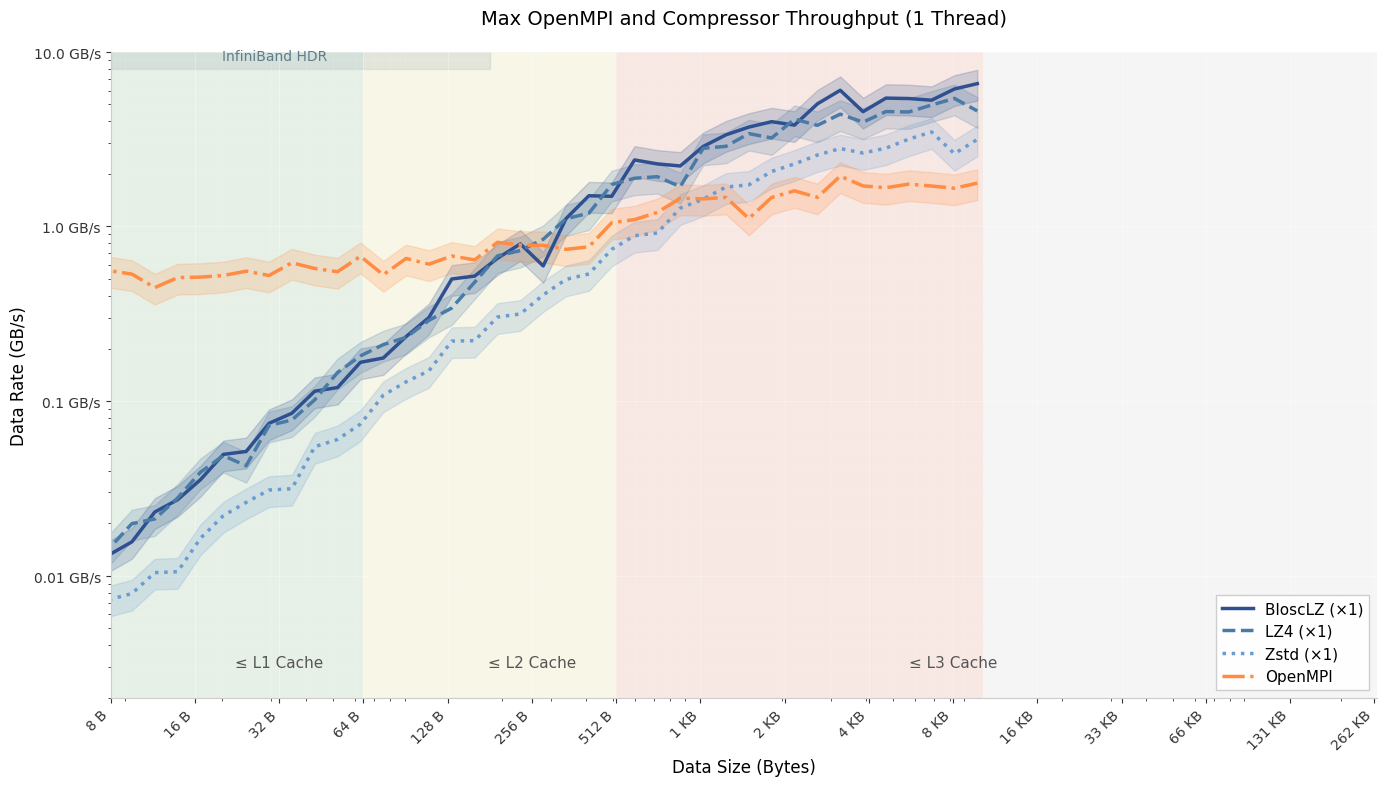

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
import matplotlib.patches as mpatches

def setup_custom_style():
    """Set up the custom matplotlib style similar to the provided visualization"""
    
    # Figure and axes settings
    rcParams['figure.figsize'] = (14, 8)
    rcParams['figure.facecolor'] = 'white'
    rcParams['figure.dpi'] = 100
    
    # Axes settings
    rcParams['axes.facecolor'] = '#f5f5f5'
    rcParams['axes.edgecolor'] = '#cccccc'
    rcParams['axes.linewidth'] = 0.8
    rcParams['axes.grid'] = True
    rcParams['axes.axisbelow'] = True
    rcParams['axes.labelsize'] = 12
    rcParams['axes.titlesize'] = 14
    rcParams['axes.titleweight'] = 'normal'
    
    # Grid settings
    rcParams['grid.color'] = 'white'
    rcParams['grid.linestyle'] = '-'
    rcParams['grid.linewidth'] = 1.0
    rcParams['grid.alpha'] = 0.8
    
    # Line settings
    rcParams['lines.linewidth'] = 2.5
    rcParams['lines.antialiased'] = True
    
    # Legend settings
    rcParams['legend.frameon'] = True
    rcParams['legend.framealpha'] = 0.9
    rcParams['legend.facecolor'] = 'white'
    rcParams['legend.edgecolor'] = '#cccccc'
    rcParams['legend.fontsize'] = 11
    rcParams['legend.loc'] = 'lower right'
    
    # Font settings
    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    rcParams['font.size'] = 11
    
    # Tick settings
    rcParams['xtick.labelsize'] = 10
    rcParams['ytick.labelsize'] = 10
    rcParams['xtick.color'] = '#333333'
    rcParams['ytick.color'] = '#333333'
    rcParams['xtick.direction'] = 'out'
    rcParams['ytick.direction'] = 'out'

def create_sample_graph():
    """Create a sample graph with the custom style"""
    
    # Apply custom style
    setup_custom_style()
    
    # Generate sample data
    x = np.logspace(0, 4, 50)  # From 1 B to 10 KB
    
    # Create different compression algorithm performances
    algorithms = {
        'BloscLZ (×1)': {
            'data': 1.5 * np.log10(x + 10) * (1 - np.exp(-x/1000)),
            'style': '-',
            'color': '#2E5090'
        },
        'LZ4 (×1)': {
            'data': 1.2 * np.log10(x + 10) * (1 - np.exp(-x/800)),
            'style': '--',
            'color': '#4A7BA7'
        },
        'Zstd (×1)': {
            'data': 0.8 * np.log10(x + 10) * (1 - np.exp(-x/1200)),
            'style': ':',
            'color': '#6A9BD1'
        },
        'OpenMPI': {
            'data': 0.3 * np.log10(x + 10) * (1 - np.exp(-x/500)) + 0.5,
            'style': '-.',
            'color': '#FF8C42'
        }
    }
    
    # Create figure and axis
    fig, ax = plt.subplots(1, 1)
    
    # Add background regions for cache levels
    # L1 Cache region
    l1_region = mpatches.Rectangle((ax.get_xlim()[0], ax.get_ylim()[0]), 
                                   64, 100, 
                                   transform=ax.transData,
                                   facecolor='#c8e6c9', 
                                   alpha=0.3, 
                                   zorder=0)
    ax.add_patch(l1_region)
    
    # L2 Cache region  
    l2_region = mpatches.Rectangle((64, ax.get_ylim()[0]), 
                                   448, 100,
                                   transform=ax.transData,
                                   facecolor='#fff9c4', 
                                   alpha=0.3, 
                                   zorder=0)
    ax.add_patch(l2_region)
    
    # L3 Cache region
    l3_region = mpatches.Rectangle((512, ax.get_ylim()[0]), 
                                   10000, 100,
                                   transform=ax.transData,
                                   facecolor='#ffccbc', 
                                   alpha=0.3, 
                                   zorder=0)
    ax.add_patch(l3_region)
    
    # Plot lines with confidence bands
    for name, props in algorithms.items():
        y = props['data']
        
        # Add some noise for variation
        y = y * (1 + 0.1 * np.random.randn(len(x)))
        
        # Plot main line
        line = ax.plot(x, y, 
                      linestyle=props['style'], 
                      color=props['color'],
                      linewidth=2.5,
                      label=name,
                      zorder=2)[0]
        
        # Add confidence band
        y_upper = y * 1.2
        y_lower = y * 0.8
        ax.fill_between(x, y_lower, y_upper, 
                       color=props['color'], 
                       alpha=0.2,
                       zorder=1)
    
    # Set scales
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Set labels and title
    ax.set_xlabel('Data Size (Bytes)', fontsize=12)
    ax.set_ylabel('Data Rate (GB/s)', fontsize=12)
    ax.set_title('Max OpenMPI and Compressor Throughput (1 Thread)', 
                fontsize=14, pad=20)
    
    # Set axis limits
    ax.set_xlim(8, 268000)
    ax.set_ylim(0.002, 10)
    
    # Format x-axis tick labels
    x_ticks = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144]
    x_labels = ['8 B', '16 B', '32 B', '64 B', '128 B', '256 B', '512 B', '1 KB', '2 KB', 
                '4 KB', '8 KB', '16 KB', '33 KB', '66 KB', '131 KB', '262 KB']
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    
    # Format y-axis tick labels
    y_ticks = [0.01, 0.1, 1.0, 10.0]
    y_labels = ['0.01 GB/s', '0.1 GB/s', '1.0 GB/s', '10.0 GB/s']
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    
    # Add text labels for cache regions
    ax.text(32, 0.003, '≤ L1 Cache', fontsize=11, ha='center', color='#555555')
    ax.text(256, 0.003, '≤ L2 Cache', fontsize=11, ha='center', color='#555555')
    ax.text(8192, 0.003, '≤ L3 Cache', fontsize=11, ha='center', color='#555555')
    
    # Add horizontal line for InfiniBand HDR reference
    ax.axhspan(8, 12, xmin=0, xmax=0.3, 
              color='#90a4ae', alpha=0.2, zorder=0)
    ax.text(20, 9, 'InfiniBand HDR', fontsize=10, color='#607d8b')
    
    # Customize legend
    legend = ax.legend(loc='lower right', 
                       frameon=True, 
                       fancybox=False,
                       shadow=False,
                       framealpha=0.95)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('#cccccc')
    
    # Fine-tune grid
    ax.grid(True, which='major', linestyle='-', linewidth=0.8, alpha=0.3, color='white')
    ax.grid(True, which='minor', linestyle='-', linewidth=0.4, alpha=0.2, color='white')
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    return fig, ax

# Example usage
if __name__ == "__main__":
    # Create and display the sample graph
    fig, ax = create_sample_graph()
    plt.show()
    
    # You can save the figure
    # fig.savefig('throughput_plot.png', dpi=150, bbox_inches='tight')

In [3]:
import jax
jax.config.update("jax_enable_x64", True)  # Enable 64-bit precision
jax.config.update("jax_debug_nans", True)
jax.config.update("jax_platforms", "cpu")
import jax.numpy as jnp
import jax.random as random
from jax import lax

import numpyro
numpyro.set_host_device_count(4)
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import orthax
import functools
import pandas as pd

from typing import Dict, Tuple, NamedTuple, Callable,  Any, Optional
from dataclasses import dataclass
from enum import Enum


def scatter_vector(theta, lambda_0=633e-9, n=1.33, radians=False):
    """
    theta - scatter angle
    lambda_0 - lsder wavelength in meters
    n - refractive index of water
    """
    if not radians:
        theta = jnp.radians(theta)
    return (4 * jnp.pi * n/lambda_0) * jnp.sin(theta / 2)

def diffusion_coef(r, k_B=1.38e-23, T=298.15, eta=0.00089):
    """
    r - particle radius
    k_b - Boltzmann constant (J/K)
    T - Temperature (K)
    eta - Viscosity of water at room temerature (Pa*s)
    """
    return k_B * T / (6 * jnp.pi * eta * r)

def normal_to_lognormal_params(mu, sigma):
    sigma_ln_sq = jnp.log(1 + (sigma / mu)**2)
    mu_ln = jnp.log(mu) - (sigma_ln_sq / 2)
    sigma_ln = jnp.sqrt(sigma_ln_sq)
    return (mu_ln, sigma_ln)

def prep_data(datafile):
    df = pd.read_csv(datafile, delimiter='\t', header=None)
    df = df.iloc[1:] # remove strange first point
    d = jnp.array(df.to_numpy())

    t = d[:, 0]
    t *=  1e-3 # convert timestamps from ms to s

    # observation data is g2(t) - 1
    g2_minus1_obs = d[:, 1:].T

    div = jax.vmap(lambda x: x/x[0])
    g1_squared = div(g2_minus1_obs) # normalization by first term handles removing the beta term (roughly)

    # g1 = jnp.sqrt(jnp.maximum(g1_squared, 0)) # this line converts to g1

    g1 = jnp.where(
        jnp.greater_equal(g1_squared, 0),
        jnp.sqrt(g1_squared),
        -jnp.sqrt(-g1_squared)
    )

    # g1 = jnp.sign(g1_squared) * jnp.sqrt(jnp.abs(g1_squared))

    theta = jnp.arange(30., 151, 5) # angles known in advance - in degrees
    q = scatter_vector(theta)
    return q, t, g1

def prep_data_g2(datafile):
    df = pd.read_csv(datafile, delimiter='\t', header=None)
    df = df.iloc[1:] # remove strange first point
    d = jnp.array(df.to_numpy())

    t = d[:, 0]
    t *=  1e-3 # convert timestamps from ms to s

    # observation data is g2(t) - 1
    g2_minus1_obs = d[:, 1:].T

    div = jax.vmap(lambda x: x/x[0])
    g1_squared = div(g2_minus1_obs) # normalization by first term handles removing the beta term (roughly)

    # # g1 = jnp.sqrt(jnp.maximum(g1_squared, 0)) # this line converts to g1
    # g1 = jnp.where(
    #     jnp.greater_equal(g1_squared, 0),
    #     jnp.sqrt(g1_squared),
    #     -jnp.sqrt(-g1_squared)
    # )

    theta = jnp.arange(30., 151, 5) # angles known in advance - in degrees
    q = scatter_vector(theta)
    # return q, t, g2_minus1_obs
    return q, t, g1_squared

### models
SCALING_CONST = 2.45e-12


######### Normal model ##########

def get_g1(t, nk, a, c):
    b = a**2/2
    d = jnp.sqrt(2)
    s_pi = jnp.sqrt(jnp.pi)
    x = (-a + c*t)/d
    y = jnp.where(
        jnp.greater_equal(x, 5),
        1/(x*s_pi),
        jax.scipy.special.erfc(x)*jnp.exp(x**2)
    )
    e = (nk/2)*jnp.exp(-b)
    return e*y

# vectorize along time dimension
all_g1 = jax.vmap(
    get_g1,
    in_axes=(0, None, None, None)
)

def source3_1(t, q, amp, mu, sig):
    ################
    const = SCALING_CONST
    # const = 1.0
    ################
    nk = amp
    sig = sig*const
    mu = mu*const
    a = mu/sig
    c = q**2*sig

    g = all_g1(t, nk, a, c)
    return g

by_Xs1 = jax.vmap(
    source3_1,
    in_axes=(None, None, 0, 0, 0)
)

source_matrix1 = jax.vmap(
    by_Xs1,
    in_axes=(None, 0, None, None, None)
)

def g1_matrix(q, t, amp, mu, sig):
    full = source_matrix1(t, q, amp, mu, sig)
    full = jnp.sum(full, axis=1)
    return full

@jax.jit
def g2_minus1_matrix(q, t, amp, mu, sig, beta):
    g1 = g1_matrix(q, t, amp, mu, sig)
    g2_minus1 = beta * g1**2
    return g2_minus1



In [ ]:
import jax
import jax.numpy as jnp
from jax import random, lax
import functools
from typing import NamedTuple
import matplotlib.pyplot as plt
from tqdm.auto import trange

# Enable 64-bit precision
jax.config.update("jax_enable_x64", True)

# ========== STATE DEFINITION ==========
class DLSState(NamedTuple):
    """State for DLS RJMCMC model."""
    k: int
    amp: jnp.ndarray
    mu: jnp.ndarray
    sig: jnp.ndarray
    beta: float
    sigma_noise: float
    log_posterior: float
    
# For tracking acceptances in JIT-compiled code
class StepInfo(NamedTuple):
    """Information about RJMCMC step."""
    state: DLSState
    accepted: bool
    move_type: int  # 0=update, 1=birth, 2=death

# ========== HELPER FUNCTIONS (JIT-COMPATIBLE) ==========

@jax.jit
def invgamma_logpdf(x, a, b):
    """Log PDF of Inverse-Gamma distribution."""
    x = jnp.maximum(x, 1e-10)
    return a * jnp.log(b) - jax.scipy.special.gammaln(a) - (a + 1) * jnp.log(x) - b / x

@jax.jit
def sample_inverse_gamma(key, a, b):
    """Sample from Inverse-Gamma(a, b)."""
    gamma_sample = random.gamma(key, a)
    return b / gamma_sample

@jax.jit
def truncated_normal_sample(key, mean, std, lower, upper):
    """Sample from truncated normal distribution using JAX functions."""
    u = random.uniform(key)
    a_std = (lower - mean) / std
    b_std = (upper - mean) / std
    
    # Use JAX's special functions for normal CDF
    cdf_a = jax.scipy.special.ndtr(a_std)
    cdf_b = jax.scipy.special.ndtr(b_std)
    
    truncated_u = cdf_a + u * (cdf_b - cdf_a)
    return mean + std * jax.scipy.special.ndtri(truncated_u)

# ========== MODEL FUNCTIONS (Already JIT-compatible) ==========

SCALING_CONST = 2.45e-12

@jax.jit
def get_g1(t, nk, a, c):
    b = a**2/2
    d = jnp.sqrt(2)
    s_pi = jnp.sqrt(jnp.pi)
    x = (-a + c*t)/d
    y = jnp.where(
        jnp.greater_equal(x, 5),
        1/(x*s_pi),
        jax.scipy.special.erfc(x)*jnp.exp(x**2)
    )
    e = (nk/2)*jnp.exp(-b)
    return e*y

all_g1 = jax.vmap(get_g1, in_axes=(0, None, None, None))

def source3_1(t, q, amp, mu, sig):
    const = SCALING_CONST
    nk = amp
    sig = sig*const
    mu = mu*const
    a = mu/sig
    c = q**2*sig
    g = all_g1(t, nk, a, c)
    return g

by_Xs1 = jax.vmap(source3_1, in_axes=(None, None, 0, 0, 0))
source_matrix1 = jax.vmap(by_Xs1, in_axes=(None, 0, None, None, None))

@jax.jit
def g1_matrix(q, t, amp, mu, sig):
    full = source_matrix1(t, q, amp, mu, sig)
    full = jnp.sum(full, axis=1)
    return full

@jax.jit
def g2_minus1_matrix(q, t, amp, mu, sig, beta):
    g1 = g1_matrix(q, t, amp, mu, sig)
    g2_minus1 = beta * g1**2
    return g2_minus1

# ========== LIKELIHOOD AND PRIOR (JIT-COMPATIBLE) ==========

@jax.jit
def log_likelihood_dls(data, q_values, t_values, state):
    """Calculate log-likelihood for DLS g2 data."""
    active_amp = state.amp[:state.k]
    active_mu = state.mu[:state.k]
    active_sig = state.sig[:state.k]
    
    # Ensure amplitudes sum to 1
    active_amp = active_amp / jnp.sum(active_amp)
    
    # Get model predictions
    g2_pred = g2_minus1_matrix(q_values, t_values, active_amp, active_mu, active_sig, state.beta)
    
    # Gaussian noise model
    residuals = data - g2_pred
    n_points = data.size
    
    log_lik = -0.5 * jnp.sum(residuals**2) / state.sigma_noise**2
    log_lik -= 0.5 * n_points * jnp.log(2 * jnp.pi * state.sigma_noise**2)
    
    return log_lik

@jax.jit
def log_prior_dls(state, k_max, prior_params):
    """Calculate log prior for DLS parameters."""
    k = state.k
    active_amp = state.amp[:k]
    active_mu = state.mu[:k]
    active_sig = state.sig[:k]
    
    # Prior on k - uniform
    log_p_k = -jnp.log(k_max)
    
    # Prior on amplitudes - Dirichlet
    active_amp_norm = active_amp / jnp.sum(active_amp)
    alpha = jnp.ones(k) * prior_params['amp_alpha']
    log_p_amp = jax.scipy.stats.dirichlet.logpdf(active_amp_norm, alpha)
    
    # Prior on mu - log-normal truncated to [0.1, 2]
    log_mu = jnp.log(active_mu)
    log_p_mu = jnp.sum(jax.scipy.stats.norm.logpdf(log_mu, prior_params['log_mu_mean'], prior_params['log_mu_std']))
    # Truncation penalty
    log_p_mu = jnp.where(
        jnp.all((active_mu >= 0.1) & (active_mu <= 2.0)),
        log_p_mu,
        -jnp.inf
    )
    
    # Prior on sig - Beta scaled to [0.065, 0.15]
    sig_scaled = (active_sig - 0.065) / (0.15 - 0.065)
    log_p_sig = jnp.sum(jax.scipy.stats.beta.logpdf(sig_scaled, a=prior_params['sig_alpha'], b=prior_params['sig_beta']))
    log_p_sig -= k * jnp.log(0.15 - 0.065)
    
    # Prior on beta
    log_p_beta = jax.scipy.stats.beta.logpdf(state.beta, a=prior_params['beta_alpha'], b=prior_params['beta_beta'])
    
    # Prior on noise - Inverse Gamma
    log_p_sigma = invgamma_logpdf(state.sigma_noise**2, prior_params['noise_a'], prior_params['noise_b'])
    log_p_sigma += jnp.log(2 * state.sigma_noise)
    
    return log_p_k + log_p_amp + log_p_mu + log_p_sig + log_p_beta + log_p_sigma

@jax.jit
def calculate_log_posterior_dls(data, q_values, t_values, state, k_max, prior_params):
    """Calculate full log posterior (JIT-compatible)."""
    active_mu = state.mu[:state.k]
    active_sig = state.sig[:state.k]
    active_amp = state.amp[:state.k]
    
    # Check validity using JAX operations
    valid_k = (state.k >= 1) & (state.k <= k_max)
    valid_mu = jnp.all((active_mu >= 0.1) & (active_mu <= 2.0))
    valid_sig = jnp.all((active_sig >= 0.065) & (active_sig <= 0.15))
    valid_amp = jnp.all(active_amp > 0)
    valid_beta = (state.beta > 0) & (state.beta < 1)
    valid_sigma = state.sigma_noise > 0
    
    all_valid = valid_k & valid_mu & valid_sig & valid_amp & valid_beta & valid_sigma
    
    log_prior = log_prior_dls(state, k_max, prior_params)
    log_lik = log_likelihood_dls(data, q_values, t_values, state)
    
    return jnp.where(all_valid, log_prior + log_lik, -jnp.inf)

# ========== JIT-COMPATIBLE RJMCMC MOVES ==========

@functools.partial(jax.jit, static_argnames=['k_max'])
def birth_move_dls(key, data, q_values, t_values, k_max, prior_params, current_state):
    """Birth move: add a new component (JIT-compatible)."""
    k = current_state.k
    
    def do_birth(key):
        key, mu_key, sig_key, amp_key, accept_key = random.split(key, 5)
        
        # Sample new parameters
        log_mu_new = random.normal(mu_key) * prior_params['log_mu_std'] + prior_params['log_mu_mean']
        mu_new = jnp.clip(jnp.exp(log_mu_new), 0.1, 2.0)
        
        sig_beta = random.beta(sig_key, prior_params['sig_alpha'], prior_params['sig_beta'])
        sig_new = 0.065 + sig_beta * (0.15 - 0.065)
        
        u = random.beta(amp_key, 1, k)
        
        # Current amplitudes
        old_amp = current_state.amp[:k]
        old_amp_norm = old_amp / jnp.sum(old_amp)
        
        # Split amplitudes
        new_component_amp = u
        existing_amp = old_amp_norm * (1 - u)
        
        # Build new state using dynamic slicing
        new_k = k + 1
        
        # Create indices for scatter
        indices = jnp.arange(k_max)
        
        # Combine parameters
        all_amp = jnp.concatenate([existing_amp, jnp.array([new_component_amp])])
        all_mu = jnp.concatenate([current_state.mu[:k], jnp.array([mu_new])])
        all_sig = jnp.concatenate([current_state.sig[:k], jnp.array([sig_new])])
        
        # Sort by mu
        sort_idx = jnp.argsort(all_mu)
        sorted_amp = all_amp[sort_idx]
        sorted_mu = all_mu[sort_idx]
        sorted_sig = all_sig[sort_idx]
        
        # Create new arrays
        prop_amp = jnp.where(indices < new_k, 
                            jnp.concatenate([sorted_amp, jnp.zeros(k_max - new_k)]),
                            0.0)
        prop_mu = jnp.where(indices < new_k,
                           jnp.concatenate([sorted_mu, jnp.zeros(k_max - new_k)]),
                           0.0)
        prop_sig = jnp.where(indices < new_k,
                            jnp.concatenate([sorted_sig, jnp.zeros(k_max - new_k)]),
                            0.0)
        
        proposed_state = DLSState(
            k=new_k,
            amp=prop_amp,
            mu=prop_mu,
            sig=prop_sig,
            beta=current_state.beta,
            sigma_noise=current_state.sigma_noise,
            log_posterior=0
        )
        
        # Calculate acceptance probability
        log_post_proposed = calculate_log_posterior_dls(data, q_values, t_values, proposed_state, k_max, prior_params)
        
        log_dim_match = jnp.log(1/(k+1))
        log_jacobian = k * jnp.log(1 - u)
        log_proposal_u = (k - 1) * jnp.log(1 - u) - jnp.log(k)
        
        log_alpha = log_post_proposed - current_state.log_posterior + log_dim_match + log_jacobian - log_proposal_u
        
        accept = jnp.log(random.uniform(accept_key)) < log_alpha
        
        new_state = proposed_state._replace(log_posterior=log_post_proposed)
        return lax.cond(accept, lambda _: new_state, lambda _: current_state, None), accept
    
    def no_birth(_):
        return current_state, False
    
    can_birth = k < k_max
    return lax.cond(can_birth, do_birth, no_birth, key)

@functools.partial(jax.jit, static_argnames=['k_max'])
def death_move_dls(key, data, q_values, t_values, k_max, prior_params, current_state):
    """Death move: remove a component (JIT-compatible)."""
    k = current_state.k
    
    def do_death(key):
        key, kill_key, accept_key = random.split(key, 3)
        
        # Choose component to kill
        j = random.randint(kill_key, (), 0, k)
        
        # Get current parameters
        current_amp = current_state.amp[:k]
        current_amp_norm = current_amp / jnp.sum(current_amp)
        current_mu = current_state.mu[:k]
        current_sig = current_state.sig[:k]
        
        # Calculate u for reverse birth move
        u = current_amp_norm[j]
        
        # Remove component using masking
        keep_mask = jnp.arange(k) != j
        new_amp = jnp.where(keep_mask, current_amp_norm, 0)
        new_amp = new_amp[keep_mask]
        new_amp = new_amp / jnp.sum(new_amp)
        
        new_mu = current_mu[keep_mask]
        new_sig = current_sig[keep_mask]
        
        # Build proposed state
        new_k = k - 1
        indices = jnp.arange(k_max)
        
        prop_amp = jnp.where(indices < new_k,
                            jnp.concatenate([new_amp, jnp.zeros(k_max - new_k + 1)]),
                            0.0)
        prop_mu = jnp.where(indices < new_k,
                           jnp.concatenate([new_mu, jnp.zeros(k_max - new_k + 1)]),
                           0.0)
        prop_sig = jnp.where(indices < new_k,
                            jnp.concatenate([new_sig, jnp.zeros(k_max - new_k + 1)]),
                            0.0)
        
        proposed_state = DLSState(
            k=new_k,
            amp=prop_amp,
            mu=prop_mu,
            sig=prop_sig,
            beta=current_state.beta,
            sigma_noise=current_state.sigma_noise,
            log_posterior=0
        )
        
        # Calculate acceptance probability
        log_post_proposed = calculate_log_posterior_dls(data, q_values, t_values, proposed_state, k_max, prior_params)
        
        log_dim_match = -jnp.log(1/k)
        log_jacobian = -(k-1) * jnp.log(1 - u)
        log_proposal_u = (k - 2) * jnp.log(1 - u) - jnp.log(k - 1)
        
        log_alpha = log_post_proposed - current_state.log_posterior + log_dim_match + log_jacobian + log_proposal_u
        
        accept = jnp.log(random.uniform(accept_key)) < log_alpha
        
        new_state = proposed_state._replace(log_posterior=log_post_proposed)
        return lax.cond(accept, lambda _: new_state, lambda _: current_state, None), accept
    
    def no_death(_):
        return current_state, False
    
    can_death = k > 1
    return lax.cond(can_death, do_death, no_death, key)

@functools.partial(jax.jit, static_argnames=['k_max'])
def within_model_update_dls(key, data, q_values, t_values, k_max, prior_params, current_state):
    """Update parameters within current model (JIT-compatible)."""
    k = current_state.k
    
    key, amp_key, mu_key, sig_key, beta_key, noise_key, accept_key = random.split(key, 7)
    
    # Get active parameters
    active_amp = current_state.amp[:k]
    active_mu = current_state.mu[:k]
    active_sig = current_state.sig[:k]
    
    # Propose new parameters
    # Amplitudes: Dirichlet centered at current
    concentration = 50.0
    prop_amp = random.dirichlet(amp_key, active_amp * concentration / jnp.sum(active_amp))
    
    # Mu: log-normal random walk
    log_mu = jnp.log(active_mu)
    prop_log_mu = log_mu + random.normal(mu_key, shape=(k,)) * 0.1
    prop_mu = jnp.clip(jnp.exp(prop_log_mu), 0.1, 2.0)
    
    # Sig: random walk on logit scale
    sig_logit = jnp.log((active_sig - 0.065) / (0.15 - active_sig))
    prop_sig_logit = sig_logit + random.normal(sig_key, shape=(k,)) * 0.2
    prop_sig = 0.065 + (0.15 - 0.065) / (1 + jnp.exp(-prop_sig_logit))
    
    # Beta: random walk on logit scale
    beta_logit = jnp.log(current_state.beta / (1 - current_state.beta))
    prop_beta_logit = beta_logit + random.normal(beta_key) * 0.1
    prop_beta = 1 / (1 + jnp.exp(-prop_beta_logit))
    
    # Noise: log-normal random walk
    log_sigma = jnp.log(current_state.sigma_noise)
    prop_log_sigma = log_sigma + random.normal(noise_key) * 0.1
    prop_sigma_noise = jnp.exp(prop_log_sigma)
    
    # Sort by mu for identifiability
    sort_idx = jnp.argsort(prop_mu)
    prop_amp = prop_amp[sort_idx]
    prop_mu = prop_mu[sort_idx]
    prop_sig = prop_sig[sort_idx]
    
    # Build proposed state
    indices = jnp.arange(k_max)
    new_amp = jnp.where(indices < k,
                       jnp.concatenate([prop_amp, jnp.zeros(k_max - k)]),
                       current_state.amp[indices])
    new_mu = jnp.where(indices < k,
                      jnp.concatenate([prop_mu, jnp.zeros(k_max - k)]),
                      current_state.mu[indices])
    new_sig = jnp.where(indices < k,
                       jnp.concatenate([prop_sig, jnp.zeros(k_max - k)]),
                       current_state.sig[indices])
    
    proposed_state = DLSState(
        k=k,
        amp=new_amp,
        mu=new_mu,
        sig=new_sig,
        beta=prop_beta,
        sigma_noise=prop_sigma_noise,
        log_posterior=0
    )
    
    # Calculate acceptance probability
    log_post_proposed = calculate_log_posterior_dls(data, q_values, t_values, proposed_state, k_max, prior_params)
    
    log_alpha = log_post_proposed - current_state.log_posterior
    
    accept = jnp.log(random.uniform(accept_key)) < log_alpha
    
    new_state = proposed_state._replace(log_posterior=log_post_proposed)
    return lax.cond(accept, lambda _: new_state, lambda _: current_state, None), accept

# ========== JIT-COMPILED STEP FUNCTION ==========

@functools.partial(jax.jit, static_argnames=['k_max'])
def rjmcmc_step(key, state, data, q_values, t_values, k_max, prior_params):
    """Single RJMCMC step (fully JIT-compiled)."""
    key, move_key, step_key = random.split(key, 3)
    
    # Choose move type
    move_probs = jnp.array([0.5, 0.25, 0.25])  # update, birth, death
    move_type = random.choice(move_key, 3, p=move_probs)
    
    # Define move functions
    def do_update(_):
        new_state, accepted = within_model_update_dls(step_key, data, q_values, t_values, k_max, prior_params, state)
        return StepInfo(state=new_state, accepted=accepted, move_type=0)
    
    def do_birth(_):
        new_state, accepted = birth_move_dls(step_key, data, q_values, t_values, k_max, prior_params, state)
        return StepInfo(state=new_state, accepted=accepted, move_type=1)
    
    def do_death(_):
        new_state, accepted = death_move_dls(step_key, data, q_values, t_values, k_max, prior_params, state)
        return StepInfo(state=new_state, accepted=accepted, move_type=2)
    
    # Execute selected move
    step_info = lax.switch(move_type, [do_update, do_birth, do_death], None)
    
    return key, step_info

# ========== LAX.SCAN APPROACH FOR FULL CHAIN ==========

@functools.partial(jax.jit, static_argnames=['n_iter', 'k_max'])
def rjmcmc_chain_scan(key, n_iter, initial_state, data, q_values, t_values, k_max, prior_params):
    """Run entire RJMCMC chain using lax.scan (fully JIT-compiled)."""
    
    # Calculate initial log posterior
    initial_state = initial_state._replace(
        log_posterior=calculate_log_posterior_dls(data, q_values, t_values, initial_state, k_max, prior_params)
    )
    
    def scan_body(carry, _):
        key, state = carry
        key, step_info = rjmcmc_step(key, state, data, q_values, t_values, k_max, prior_params)
        return (key, step_info.state), step_info
    
    (final_key, final_state), step_infos = lax.scan(scan_body, (key, initial_state), jnp.arange(n_iter))
    
    return step_infos

# ========== PYTHON WRAPPER FOR PROGRESS TRACKING ==========

def rjmcmc_sampler_jit(key, n_iter, initial_state, data, q_values, t_values, 
                       k_max, prior_params, verbose=True, use_scan=False):
    """
    RJMCMC sampler with JIT compilation.
    
    Args:
        use_scan: If True, use lax.scan for entire chain (faster but no progress updates).
                 If False, use Python loop with JIT-compiled steps (allows progress tracking).
    """
    
    if use_scan:
        # Run entire chain at once with lax.scan
        print("Running RJMCMC with lax.scan (no progress updates)...")
        step_infos = rjmcmc_chain_scan(key, n_iter, initial_state, data, q_values, 
                                       t_values, k_max, prior_params)
        
        # Extract samples
        samples = {
            'k': step_infos.state.k,
            'beta': step_infos.state.beta,
            'sigma_noise': step_infos.state.sigma_noise,
            'log_posterior': step_infos.state.log_posterior,
            'accepted': step_infos.accepted,
            'move_type': step_infos.move_type
        }
        
        # Calculate acceptance rates
        n_accept = {
            'update': jnp.sum((step_infos.move_type == 0) & step_infos.accepted),
            'birth': jnp.sum((step_infos.move_type == 1) & step_infos.accepted),
            'death': jnp.sum((step_infos.move_type == 2) & step_infos.accepted)
        }
        n_propose = {
            'update': jnp.sum(step_infos.move_type == 0),
            'birth': jnp.sum(step_infos.move_type == 1),
            'death': jnp.sum(step_infos.move_type == 2)
        }
        
    else:
        # Python loop with progress tracking
        current_state = initial_state._replace(
            log_posterior=calculate_log_posterior_dls(data, q_values, t_values, 
                                                     initial_state, k_max, prior_params)
        )
        
        samples = {
            'k': [],
            'beta': [],
            'sigma_noise': [],
            'log_posterior': [],
            'accepted': [],
            'move_type': []
        }
        
        n_accept = {'update': 0, 'birth': 0, 'death': 0}
        n_propose = {'update': 0, 'birth': 0, 'death': 0}
        
        iterator = trange(n_iter, desc="RJMCMC-JIT") if verbose else range(n_iter)
        
        for i in iterator:
            key, step_info = rjmcmc_step(key, current_state, data, q_values, t_values, 
                                        k_max, prior_params)
            
            current_state = step_info.state
            
            # Track acceptance
            move_names = ['update', 'birth', 'death']
            move_name = move_names[step_info.move_type]
            n_propose[move_name] += 1
            if step_info.accepted:
                n_accept[move_name] += 1
            
            # Store samples
            samples['k'].append(current_state.k)
            samples['beta'].append(current_state.beta)
            samples['sigma_noise'].append(current_state.sigma_noise)
            samples['log_posterior'].append(current_state.log_posterior)
            samples['accepted'].append(step_info.accepted)
            samples['move_type'].append(step_info.move_type)
            
            # Update progress bar
            if verbose and (i + 1) % 50 == 0:
                acc_rates = {
                    move: n_accept[move] / max(n_propose[move], 1) 
                    for move in ['update', 'birth', 'death']
                }
                iterator.set_postfix({
                    'k': current_state.k,
                    'beta': f"{current_state.beta:.3f}",
                    'acc_u': f"{acc_rates['update']:.2f}",
                    'acc_b': f"{acc_rates['birth']:.2f}",
                    'acc_d': f"{acc_rates['death']:.2f}"
                })
        
        # Convert to arrays
        for key in samples:
            samples[key] = jnp.array(samples[key])
    
    # Print final acceptance rates
    if verbose:
        print("\nFinal acceptance rates:")
        for move in ['update', 'birth', 'death']:
            rate = n_accept[move] / max(n_propose[move], 1)
            print(f"  {move:8s}: {rate:.3f} ({n_accept[move]}/{n_propose[move]})")
    
    samples['acceptance_rates'] = {
        move: n_accept[move] / max(n_propose[move], 1) 
        for move in ['update', 'birth', 'death']
    }
    
    return samples

# ========== PLOTTING UTILITIES ==========

def plot_jit_results(samples, data, q_values, t_values, burn_in=1000):
    """Plot results from JIT-compiled RJMCMC."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # Remove burn-in
    k_samples = samples['k'][burn_in:]
    beta_samples = samples['beta'][burn_in:]
    sigma_samples = samples['sigma_noise'][burn_in:]
    logpost_samples = samples['log_posterior'][burn_in:]
    
    # 1. Trace plot of k
    axes[0, 0].plot(k_samples)
    axes[0, 0].set_title("Trace: Number of Components (k)")
    axes[0, 0].set_xlabel("Iteration")
    axes[0, 0].set_ylabel("k")
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Posterior of k
    unique_k, counts = jnp.unique(k_samples, return_counts=True)
    posterior_probs = counts / len(k_samples)
    axes[0, 1].bar(unique_k, posterior_probs, alpha=0.7)
    axes[0, 1].set_title("Posterior Distribution of k")
    axes[0, 1].set_xlabel("Number of Components")
    axes[0, 1].set_ylabel("Probability")
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Log posterior trace
    axes[0, 2].plot(logpost_samples)
    axes[0, 2].set_title("Trace: Log Posterior")
    axes[0, 2].set_xlabel("Iteration")
    axes[0, 2].set_ylabel("Log Posterior")
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Beta histogram
    axes[1, 0].hist(beta_samples, bins=30, density=True, alpha=0.7)
    axes[1, 0].set_title("Posterior: Beta (Coherence)")
    axes[1, 0].set_xlabel("Beta")
    axes[1, 0].set_ylabel("Density")
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Noise histogram
    axes[1, 1].hist(sigma_samples, bins=30, density=True, alpha=0.7)
    axes[1, 1].set_title("Posterior: Noise (σ)")
    axes[1, 1].set_xlabel("Noise σ")
    axes[1, 1].set_ylabel("Density")
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Acceptance rates over time (if available)
    if 'accepted' in samples:
        window = 100
        acceptance_rate = jnp.convolve(samples['accepted'].astype(float), 
                                       jnp.ones(window)/window, mode='valid')
        axes[1, 2].plot(acceptance_rate)
        axes[1, 2].set_title(f"Acceptance Rate (window={window})")
        axes[1, 2].set_xlabel("Iteration")
        axes[1, 2].set_ylabel("Rate")
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# ========== EXAMPLE USAGE ==========

if __name__ == "__main__":
    # Import necessary functions for data preparation
    from prep_data_functions import prep_data_g2  # You'll need to include this
    
    # Setup
    key = random.PRNGKey(1337)
    
    # Generate or load data
    key, data_key = random.split(key)
    
    # Example: Generate synthetic data for testing
    q_vals = jnp.linspace(1e6, 3e7, 25)  # Example q values
    t_vals = jnp.logspace(-6, -1, 100)   # Example time points
    
    # True parameters
    true_params = {
        'k': 2,
        'beta': 0.8,
        'amp': jnp.array([0.6, 0.4]),
        'mu': jnp.array([0.5, 1.2]),
        'sig': jnp.array([0.08, 0.10]),
        'sigma': 0.001
    }
    
    # Generate data
    true_g2 = g2_minus1_matrix(
        q_vals, t_vals,
        true_params['amp'], true_params['mu'], true_params['sig'], true_params['beta']
    )
    data = true_g2 + true_params['sigma'] * random.normal(data_key, shape=true_g2.shape)
    
    print(f"Data shape: {data.shape}")
    print(f"True parameters: k={true_params['k']}, beta={true_params['beta']:.3f}")
    
    # Set priors
    k_max = 5
    prior_params = {
        'amp_alpha': 1.0,
        'log_mu_mean': jnp.log(0.5),
        'log_mu_std': 0.5,
        'sig_alpha': 2.0,
        'sig_beta': 2.0,
        'beta_alpha': 5.0,
        'beta_beta': 2.0,
        'noise_a': 2.0,
        'noise_b': 0.0001,
    }
    
    # Initialize
    initial_k = 1
    initial_amp = jnp.zeros(k_max).at[:initial_k].set(1.0)
    initial_mu = jnp.zeros(k_max).at[:initial_k].set(0.7)
    initial_sig = jnp.zeros(k_max).at[:initial_k].set(0.09)
    initial_beta = 0.7
    initial_sigma = 0.01
    
    initial_state = DLSState(
        k=initial_k,
        amp=initial_amp,
        mu=initial_mu,
        sig=initial_sig,
        beta=initial_beta,
        sigma_noise=initial_sigma,
        log_posterior=0.0
    )
    
    # Run RJMCMC with step function (allows progress tracking)
    n_iter = 300
    burn_in = 1000
    
    print("\nRunning RJMCMC with JIT-compiled steps...")
    key, sampler_key = random.split(key)
    samples_step = rjmcmc_sampler_jit(
        key=sampler_key,
        n_iter=n_iter,
        initial_state=initial_state,
        data=data,
        q_values=q_vals,
        t_values=t_vals,
        k_max=k_max,
        prior_params=prior_params,
        verbose=True,
        use_scan=False  # Use step function with progress bar
    )
    
    # Run RJMCMC with lax.scan (faster, no progress tracking)
    print("\nRunning RJMCMC with lax.scan...")
    key, sampler_key = random.split(key)
    samples_scan = rjmcmc_sampler_jit(
        key=sampler_key,
        n_iter=n_iter,
        initial_state=initial_state,
        data=data,
        q_values=q_vals,
        t_values=t_vals,
        k_max=k_max,
        prior_params=prior_params,
        verbose=True,
        use_scan=True  # Use lax.scan for entire chain
    )
    
    # Compare timing
    import time
    
    # Time step function approach
    key, timer_key = random.split(key)
    start = time.time()
    _ = rjmcmc_sampler_jit(timer_key, 1000, initial_state, data, q_vals, t_vals, 
                          k_max, prior_params, verbose=False, use_scan=False)
    step_time = time.time() - start
    
    # Time lax.scan approach
    key, timer_key = random.split(key)
    start = time.time()
    _ = rjmcmc_sampler_jit(timer_key, 1000, initial_state, data, q_vals, t_vals, 
                          k_max, prior_params, verbose=False, use_scan=True)
    scan_time = time.time() - start
    
    print(f"\nTiming comparison (1000 iterations):")
    print(f"  Step function: {step_time:.2f} seconds")
    print(f"  Lax.scan:      {scan_time:.2f} seconds")
    print(f"  Speedup:       {step_time/scan_time:.1f}x")
    
    # Plot results
    fig = plot_jit_results(samples_scan, data, q_vals, t_vals, burn_in=burn_in)
    plt.show()
    
    # Print summary
    k_samples = samples_scan['k'][burn_in:]
    unique_k, counts = jnp.unique(k_samples, return_counts=True)
    posterior_probs = counts / len(k_samples)
    
    print("\n" + "="*50)
    print("POSTERIOR SUMMARY")
    print("="*50)
    print(f"\nPosterior probabilities for k:")
    for k_val, prob in sorted(zip(unique_k, posterior_probs), key=lambda x: -x[1]):
        stars = "*" if k_val == true_params['k'] else " "
        print(f"  P(k={k_val} | data) = {prob:.4f} {stars}")
    
    print(f"\nBeta posterior: {jnp.mean(samples_scan['beta'][burn_in:]):.3f} ± {jnp.std(samples_scan['beta'][burn_in:]):.3f}")
    print(f"True beta: {true_params['beta']:.3f}")

Data shape: (25, 100)
True parameters: k=2, beta=0.800

Running RJMCMC with JIT-compiled steps...


ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape int64[]
It arose in the jnp.arange argument 'stop'
The error occurred while tracing the function get_active_params at /tmp/ipykernel_23406/4126824469.py:105 for jit. This concrete value was not available in Python because it depends on the value of the argument k_max.

See https://docs.jax.dev/en/latest/errors.html#jax.errors.ConcretizationTypeError